# RAM 代码实现详解：Reinforce Adjoint Matching

> 论文：*Reinforce Adjoint Matching: Scaling RL Post-Training of Diffusion and Flow-Matching Models*  
> arXiv: https://arxiv.org/abs/2605.10759  
> 开源项目：`/home/zhangjinrui/my_program_code/毕业论文/开源模型参考/RL/ram`

这个 notebook 做一个最简 RAM demo：不用 SD3、不下载奖励模型，只用二维 flow-matching toy model 复现 RAM 的核心训练逻辑。

真实项目里：

- base/reference model = 冻结的 SD3.5 Medium；
- policy = 当前可训练 LoRA adapter；
- old = lagged/EMA adapter，用来构造稳定 target；
- evaluation = 更平滑的 EMA adapter，用来评估；
- reward = GenEval / OCR / PickScore 等不可微外部打分器。

本 demo 里：

- 用一个小 MLP 代替 SD3 Transformer；
- 用二维点分布代替图像 latent；
- 用手写 reward 函数代替外部 reward model；
- 用复制出来的三个小网络代替三套 LoRA adapter。

## 一、RAM 的核心点提炼

RAM 解决的是：如何用不可微 reward 对 diffusion / flow-matching 生成模型做 RL post-training，同时避免 DDPO / Flow-GRPO 那类多步 SDE rollout 的高成本和高方差。

核心结论可以压缩成 8 点：

1. **RL post-training 的目标是 KL-regularized reward maximization**  
   目标分布是 $p_0^*(x) \propto p_0^{ref}(x)\exp(r(x))$。reward 把概率质量推向高分样本，KL anchor 防止偏离预训练分布太远。

2. **flow matching 学的是 velocity field**  
   线性 noising：$X_t=(1-t)X_0+t\epsilon$。标准 FM target 是 $\epsilon-X_0$。

3. **RAM 不反传 reward gradient**  
   reward 可以是 GenEval、OCR、PickScore、人工偏好模型等不可微黑盒。RAM 用 REINFORCE identity，把 reward gradient 换成 reward-weighted bridge score。

4. **endpoint sampling + analytic noising**  
   先用当前模型 ODE sampler 生成 clean endpoint $X_0$，打一次 reward；再对同一个 endpoint 解析加噪出 $K$ 个训练状态 $X_t$。这摊薄了采样和 reward 评估成本。

5. **Bayes bridge score 给出闭式方向**  
   对线性 noising，关键方向是 $\epsilon-X_0$ 与当前/旧 velocity 的差。工程上不需要模拟整条 SDE 轨迹。

6. **RAM loss 是 supervised regression 形态**  
   论文理想式：
   $$
   v_\theta(X_t) \leftarrow v_{ref}(X_t)+r(X_0)((\epsilon-X_0)-v_\theta(X_t))
   $$
   target stop-gradient，只对左侧当前 velocity 反传。

7. **开源实现的稳定化版本（论文 Eq.17 的工程近似）**  
   代码中把原始 reward 换成 group/epoch-normalized advantage，并把 target 里的当前 policy 换成 lagged `old` adapter：
   $$
   \hat v = v_{ref}(X_t)+\alpha A(X_0)((\epsilon-X_0)-v_{old}(X_t))
   $$
   其中 $\alpha$ 是 `reward_multiplier`。`old` 近似公式 stop-gradient 中的当前 $v_\theta$；它不是额外的 reference/KL 模型。

8. **三套 adapter 的职责**  
   `default` 可训练；`old` 是短 EMA，用于稳定 target 和采样；`evaluation` 是更平滑 EMA，用于验证/汇报。

## 二、RAM 与开源代码的对应关系

| 知识点 | 论文公式/算法 | 开源代码位置 | 本 demo 对应 |
|---|---|---|---|
| endpoint sampling | Algorithm 1 第 1 行 | `sample_epoch()` 调 SD3 pipeline | `ode_sample(old_policy, prompt_ids)` |
| reward 打分 | $r(X_0)$ | `reward_fns` / GenEval / OCR / PickScore | `reward_fn(x0, prompt_ids)` |
| group advantage | 工程稳定化 | `sample_epoch()` 中按 prompt 归一化 | `group_advantages()` |
| analytic noising | $X_t=(1-t)X_0+t\epsilon$ | `compute_loss()` | `xt = (1-t)*x0 + t*eps` |
| velocity target | Eq. RAM loss | `target_velocity = base_v + scaled_adv * (reward_direction - old_v)` | 同公式 |
| stop-gradient | `sg(...)` | `with torch.no_grad()` + `.detach()` | `with torch.no_grad()` |
| 多 target 复用 | $K$ targets per endpoint | `num_loss_targets_per_sample` | `K` |
| timestep sampling | 训练时间步分布 | `sample_timesteps()` | `sample_t()` |
| lagged policy | old adapter | `update_lagged_params()` | `ema_update(policy, old_policy)` |
| eval EMA | evaluation adapter | `evaluation` LoRA | `eval_policy` |

## 三、导入依赖与超参数

如果这里报 `ModuleNotFoundError: No module named 'torch'`，说明当前 Jupyter kernel 没有 PyTorch。这个 demo 不需要 GPU，但需要 PyTorch CPU 版本。

In [1]:
import math
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 固定随机种子，保证 demo 可复现
seed = 7
torch.manual_seed(seed)
np.random.seed(seed)

device = "cpu"

# ---- toy data / model ----
DATA_DIM = 2
NUM_PROMPTS = 2
EMB_DIM = 4
HIDDEN = 64

# ---- 预训练 reference model ----
PRETRAIN_STEPS = 600
REF_BATCH = 256
LR_REF = 2e-3

# ---- RAM post-training ----
RAM_EPOCHS = 80
NUM_PROMPTS_PER_EPOCH = 8
NUM_SAMPLES_PER_PROMPT = 6      # 每个 prompt 采多少 endpoint
K = 4                           # 每个 endpoint 解析加噪多少个 loss target
LOSS_BATCH = 64
SAMPLER_STEPS = 32
LR_RAM = 8e-4
REWARD_MULTIPLIER = 2.0
EMA_DECAY_OLD = 0.90
EMA_DECAY_EVAL = 0.95
TIMESTEP_SAMPLING = "power_law" # 官方模式："power_law" or "logit_normal"
POWER_LAW_ALPHA = 1.0
LOGIT_NORMAL_MEAN = 0.0
LOGIT_NORMAL_STD = 1.0
REWARD_SCALING = "epoch"        # 论文实验：组内减均值 + 当前 step pooled std

print(torch.__version__)

2.0.1+cu118


## 四、构造二维 prompt-conditioned reference 分布

真实 text-to-image 里，prompt embedding 来自文本编码器，endpoint 是图像 latent。这里用两个 prompt：

- prompt 0 的参考分布中心在 `(-1, 0)`；
- prompt 1 的参考分布中心在 `(1, 0)`。

RAM 的 reward 会把二者分别推向交叉目标：prompt 0 推到右上，prompt 1 推到左上。这样可以直观看到 RL post-training 改变 endpoint 分布。

In [2]:
prompt_table = torch.eye(NUM_PROMPTS, EMB_DIM, device=device)

ref_centers = torch.tensor([[-1.0, 0.0], [1.0, 0.0]], device=device)
reward_targets = torch.tensor([[1.25, 1.0], [-1.25, 1.0]], device=device)


def sample_reference_data(prompt_ids):
    """模拟预训练数据分布 p0_ref(x | prompt)。"""
    centers = ref_centers[prompt_ids]
    return centers + 0.35 * torch.randn(len(prompt_ids), DATA_DIM, device=device)


def reward_fn(x0, prompt_ids):
    """不可微外部 reward 的 toy 版本。

    真实 RAM 中这里可以是 GenEval/OCR/PickScore。训练时不需要对 reward 反传。
    这里 reward 越接近 prompt 对应 target 越高。
    """
    target = reward_targets[prompt_ids]
    return -((x0 - target) ** 2).sum(dim=-1)

## 五、Tiny velocity network：代替 SD3 Transformer

真实 SD3 是在 latent、time、prompt embedding 上预测 velocity。这里用 MLP：

$$v_\theta(x_t,t,c) \in \mathbb R^2$$

In [3]:
class TinyVelocityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(DATA_DIM + 1 + EMB_DIM, HIDDEN),
            nn.SiLU(),
            nn.Linear(HIDDEN, HIDDEN),
            nn.SiLU(),
            nn.Linear(HIDDEN, DATA_DIM),
        )

    def forward(self, x, t, prompt_ids):
        if t.ndim == 1:
            t = t[:, None]
        emb = prompt_table[prompt_ids].to(x.device)
        inp = torch.cat([x, t, emb], dim=-1)
        return self.net(inp)

## 六、先做 flow matching 预训练：得到 reference velocity

RAM 是 post-training 方法，所以先需要一个 reference model。标准 flow matching loss：

$$
\mathcal L_{FM}=\mathbb E\|v_\theta(X_t,t,c)-(\epsilon-X_0)\|^2,
\quad X_t=(1-t)X_0+t\epsilon
$$

这一步对应大模型场景中的“已经预训练好的 SD3”。

final reference FM loss = 0.5520


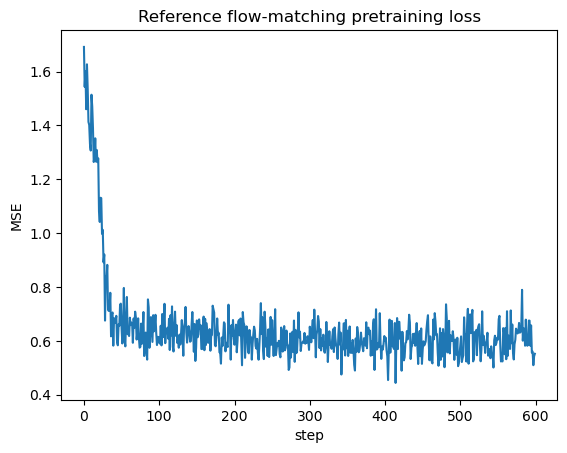

In [4]:
def flow_matching_loss(model, batch_size=REF_BATCH):
    prompt_ids = torch.randint(0, NUM_PROMPTS, (batch_size,), device=device)
    x0 = sample_reference_data(prompt_ids)
    eps = torch.randn_like(x0)
    t = torch.rand(batch_size, 1, device=device) * 0.98 + 0.01
    xt = (1 - t) * x0 + t * eps
    target_v = eps - x0
    pred_v = model(xt, t.squeeze(-1), prompt_ids)
    return F.mse_loss(pred_v, target_v)


ref_model = TinyVelocityNet().to(device)
opt_ref = torch.optim.AdamW(ref_model.parameters(), lr=LR_REF)
ref_losses = []

for step in range(PRETRAIN_STEPS):
    loss = flow_matching_loss(ref_model)
    opt_ref.zero_grad()
    loss.backward()
    opt_ref.step()
    ref_losses.append(loss.item())

for p in ref_model.parameters():
    p.requires_grad_(False)

print(f"final reference FM loss = {ref_losses[-1]:.4f}")
plt.plot(ref_losses)
plt.title("Reference flow-matching pretraining loss")
plt.xlabel("step")
plt.ylabel("MSE")
plt.show()

## 七、ODE sampler：从噪声积分到 clean endpoint

Flow-matching 采样使用 probability-flow ODE：

$$dX_t = v_t(X_t)dt$$

从 $t=1$ 的 Gaussian noise 积分到 $t=0$ 得到 endpoint $X_0$。真实代码里这一步由 SD3 pipeline 完成。

In [5]:
@torch.no_grad()
def ode_sample(model, prompt_ids, n_steps=SAMPLER_STEPS):
    model.eval()
    x = torch.randn(len(prompt_ids), DATA_DIM, device=device)
    ts = torch.linspace(1.0, 0.0, n_steps + 1, device=device)
    for i in range(n_steps):
        t = ts[i].repeat(len(prompt_ids))
        dt = ts[i + 1] - ts[i]  # negative
        x = x + dt * model(x, t, prompt_ids)
    return x


@torch.no_grad()
def evaluate_model(model, n_per_prompt=300):
    ids = torch.arange(NUM_PROMPTS, device=device).repeat_interleave(n_per_prompt)
    x = ode_sample(model, ids, n_steps=64)
    rewards = reward_fn(x, ids)
    return x.cpu(), ids.cpu(), rewards.mean().item()


x_ref, ids_ref, r_ref = evaluate_model(ref_model)
print(f"reference average reward = {r_ref:.3f}")

reference average reward = -6.364


## 八、RAM 辅助函数：timestep sampling、advantage、EMA

开源代码中三个重要工程技巧：

1. `sample_timesteps()`：不要只均匀采样时间步，可偏向高噪声端；
2. group-relative advantage：同 prompt 组内减均值；论文实验再除以当前训练 step 所有样本的 pooled std，而不是每组各自 std；
3. EMA lagged adapters：`old` 稳定 target，`evaluation` 稳定评估。

In [6]:
def sample_t(n, mode=TIMESTEP_SAMPLING):
    """连续版官方 timestep 分布，返回 RAM 坐标系 t∈(0,1)。

    RAM/SD3 约定 t=0 是数据、t=1 是噪声。power-law 的密度正比于
    t**alpha，因此逆 CDF 为 t=U**(1/(alpha+1))，alpha>0 会偏向高噪声端。
    注意 ``1-U**(...)`` 会把方向反过来，是本笔记旧版本的错误。
    """
    if mode == "logit_normal":
        u = torch.randn(n, device=device) * LOGIT_NORMAL_STD + LOGIT_NORMAL_MEAN
        return torch.sigmoid(u).clamp(0.001, 0.999)
    if mode == "power_law":
        u = torch.rand(n, device=device)
        return u.pow(1.0 / (POWER_LAW_ALPHA + 1.0)).clamp(0.001, 0.999)
    raise ValueError(mode)


def group_advantages(rewards, group_size, scale=REWARD_SCALING):
    """先逐 prompt/scene 组减均值，再选择统一的缩放方式。

    rewards: [num_groups * G]，同组 G 个样本必须连续排列。
    epoch: 与论文/官方默认一致，除以当前训练 step 全部 reward 的
           population std；多卡时真实工程还需先跨 rank 汇总统计量。
    group: 每组各除自己的 std（官方支持，但论文指出相同 reward 组不稳）。
    none: 只中心化，不缩放。
    """
    if rewards.numel() % group_size != 0:
        raise ValueError("rewards 数量必须能被 group_size 整除")
    groups = rewards.reshape(-1, group_size)             # [num_groups,G]
    centered = groups - groups.mean(dim=1, keepdim=True) # [num_groups,G]
    if scale == "epoch":
        centered = centered / (rewards.std(correction=0) + 1e-4)
    elif scale == "group":
        centered = centered / (groups.std(dim=1, correction=0, keepdim=True) + 1e-4)
    elif scale != "none":
        raise ValueError("scale 必须是 'epoch'、'group' 或 'none'")
    return centered.reshape_as(rewards)


@torch.no_grad()
def ema_update(source, target, decay):
    for s, t in zip(source.parameters(), target.parameters()):
        t.data.mul_(decay).add_(s.data, alpha=1 - decay)


# 统计检查：alpha=1 的 power-law 均值理论上为 2/3，应明显大于 0.5。
probe_t = sample_t(20000, "power_law")
print(f"power-law mean(t)={probe_t.mean().item():.3f} (alpha=1 理论值约 0.667)")
assert probe_t.mean() > 0.6


power-law mean(t)=0.669 (alpha=1 理论值约 0.667)


## 九、初始化 RAM 的三套网络

真实开源项目在一个 SD3 Transformer 上挂三套 LoRA adapter：

- `default`：可训练 policy；
- `old`：lagged policy，采样和 target construction 使用；
- `evaluation`：更平滑的 EMA，用于 validation。

本 demo 用三份 MLP 拷贝模拟。

In [7]:
policy = deepcopy(ref_model).to(device)
old_policy = deepcopy(ref_model).to(device)
eval_policy = deepcopy(ref_model).to(device)

for p in policy.parameters():
    p.requires_grad_(True)
for m in [old_policy, eval_policy]:
    for p in m.parameters():
        p.requires_grad_(False)

opt_ram = torch.optim.AdamW(policy.parameters(), lr=LR_RAM)

## 十、RAM 单 epoch：核心公式实现

这就是 RAM demo 的核心。流程：

1. 用 `old_policy` 采样 endpoint $X_0$；
2. 用 reward function 给 endpoint 打分；
3. 同 prompt 组内减均值，并用当前 step pooled std 缩放得到 advantage $A$；
4. 每个 endpoint 复制 $K$ 次，采样 $t,\epsilon$，解析构造 $X_t$；
5. 构造 stop-gradient velocity target：

$$
\hat v = v_{ref}(X_t) + \alpha A\left((\epsilon-X_0)-v_{old}(X_t)\right)
$$

6. 只回归当前 `policy(X_t,t,c)` 到 $\hat v$。

注意：没有 reward gradient，没有 SDE rollout，也没有对采样轨迹反传。

In [8]:
def ram_epoch(epoch):
    # ---- 1) 组织 prompts：每个 prompt 多采样，才能做 group-relative advantage ----
    prompts_once = torch.arange(NUM_PROMPTS, device=device).repeat_interleave(
        NUM_PROMPTS_PER_EPOCH // NUM_PROMPTS
    )
    prompt_ids = prompts_once.repeat_interleave(NUM_SAMPLES_PER_PROMPT)

    # ---- 2) on-policy endpoint sampling + reward scoring ----
    with torch.no_grad():
        x0 = ode_sample(old_policy, prompt_ids)
        rewards = reward_fn(x0, prompt_ids)
        advantages = group_advantages(rewards, NUM_SAMPLES_PER_PROMPT, scale=REWARD_SCALING)

    # ---- 3) 每个 endpoint 复用 K 次：analytic noising 构造训练状态 ----
    x0_k = x0.repeat_interleave(K, dim=0)
    prompt_ids_k = prompt_ids.repeat_interleave(K, dim=0)
    adv_k = advantages.repeat_interleave(K, dim=0)

    n = len(x0_k)
    eps = torch.randn_like(x0_k)
    t = sample_t(n)
    xt = (1 - t[:, None]) * x0_k + t[:, None] * eps
    reward_direction = eps - x0_k

    # ---- 4) mini-batch regression：target 必须 stop-gradient ----
    order = torch.randperm(n, device=device)
    total_loss = 0.0

    for start in range(0, n, LOSS_BATCH):
        idx = order[start:start + LOSS_BATCH]

        with torch.no_grad():
            base_v = ref_model(xt[idx], t[idx], prompt_ids_k[idx])
            old_v = old_policy(xt[idx], t[idx], prompt_ids_k[idx])
            target_v = base_v + REWARD_MULTIPLIER * adv_k[idx, None] * (reward_direction[idx] - old_v)

        pred_v = policy(xt[idx], t[idx], prompt_ids_k[idx])
        loss = F.mse_loss(pred_v, target_v)

        opt_ram.zero_grad()
        loss.backward()
        opt_ram.step()
        total_loss += loss.item() * len(idx)

    # ---- 5) 更新 lagged adapters ----
    ema_update(policy, old_policy, EMA_DECAY_OLD)
    ema_update(policy, eval_policy, EMA_DECAY_EVAL)

    return {
        "loss": total_loss / n,
        "reward": rewards.mean().item(),
        "abs_advantage": advantages.abs().mean().item(),
    }

## 十一、运行 RAM post-training

如果训练正常，reward 会整体上升，也就是 endpoint 分布会向 reward target 移动。toy 问题很小，曲线会有噪声；重点看 before/after 的分布移动。

epoch=000 loss=1.8799 sample_reward=-6.285 abs_adv=0.787


epoch=010 loss=1.1156 sample_reward=-5.477 abs_adv=0.688


epoch=020 loss=1.2723 sample_reward=-4.415 abs_adv=0.721


epoch=030 loss=1.4381 sample_reward=-4.291 abs_adv=0.776


epoch=040 loss=1.1806 sample_reward=-4.417 abs_adv=0.755
epoch=050 loss=1.9522 sample_reward=-4.168 abs_adv=0.698


epoch=060 loss=1.6699 sample_reward=-4.266 abs_adv=0.752
epoch=070 loss=0.8359 sample_reward=-3.876 abs_adv=0.589


epoch=079 loss=1.2196 sample_reward=-4.028 abs_adv=0.740


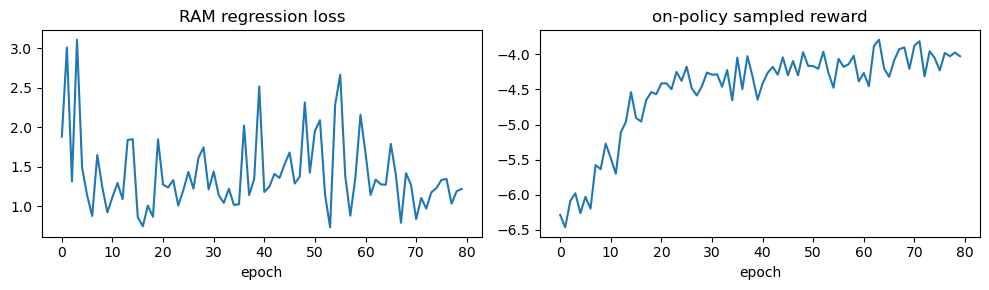

In [9]:
history = []

for epoch in range(RAM_EPOCHS):
    metrics = ram_epoch(epoch)
    history.append(metrics)
    if epoch % 10 == 0 or epoch == RAM_EPOCHS - 1:
        print(
            f"epoch={epoch:03d} "
            f"loss={metrics['loss']:.4f} "
            f"sample_reward={metrics['reward']:.3f} "
            f"abs_adv={metrics['abs_advantage']:.3f}"
        )

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot([h["loss"] for h in history])
plt.title("RAM regression loss")
plt.xlabel("epoch")

plt.subplot(1, 2, 2)
plt.plot([h["reward"] for h in history])
plt.title("on-policy sampled reward")
plt.xlabel("epoch")
plt.tight_layout()
plt.show()

## 十二、可视化：reference vs RAM-post-trained endpoint

真实论文里可视化的是 SD3 生成图片质量和 GenEval/OCR/PickScore 指标；这里看二维 endpoint 分布是否向 reward target 移动。

reference average reward = -6.288
RAM eval average reward = -4.251


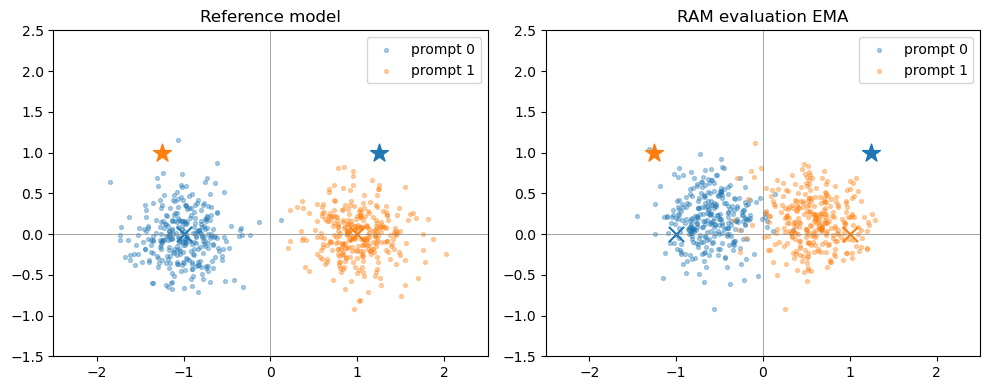

In [10]:
x_ref, ids_ref, r_ref = evaluate_model(ref_model)
x_ram, ids_ram, r_ram = evaluate_model(eval_policy)

print(f"reference average reward = {r_ref:.3f}")
print(f"RAM eval average reward = {r_ram:.3f}")

plt.figure(figsize=(10, 4))

for panel, (title, x, ids) in enumerate([
    ("Reference model", x_ref, ids_ref),
    ("RAM evaluation EMA", x_ram, ids_ram),
], start=1):
    plt.subplot(1, 2, panel)
    for pid, color in [(0, "tab:blue"), (1, "tab:orange")]:
        pts = x[ids == pid]
        plt.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.35, label=f"prompt {pid}", c=color)
        plt.scatter(ref_centers[pid, 0].cpu(), ref_centers[pid, 1].cpu(), marker="x", s=120, c=color)
        plt.scatter(reward_targets[pid, 0].cpu(), reward_targets[pid, 1].cpu(), marker="*", s=180, c=color)
    plt.axhline(0, color="gray", lw=0.5)
    plt.axvline(0, color="gray", lw=0.5)
    plt.xlim(-2.5, 2.5)
    plt.ylim(-1.5, 2.5)
    plt.title(title)
    plt.legend()

plt.tight_layout()
plt.show()

## 十三、和 RAM 开源项目的关键代码对照

开源 RAM 的主训练文件是：

`/home/zhangjinrui/my_program_code/毕业论文/开源模型参考/RL/ram/scripts/training_sd3.py`

最重要的函数：

1. `build_pipeline()`  
   加载 SD3.5 Medium，冻结 VAE/text encoder/base transformer，并挂三套 LoRA adapter：`default`、`old`、`evaluation`。

2. `sample_epoch()`  
   用 `old` adapter 采样图片 latent，decode 成图片，调用 reward model 打分，然后按 prompt group 算 advantage。

3. `compute_loss()`  
   RAM loss 的核心实现：
   ```python
   sample = (1 - sigma) * latent + sigma * noise
   reward_direction = noise - latent
   target_velocity = scaled_adv * (reward_direction - old_v) + base_v
   loss = mse(policy_v, stopgrad(target_velocity))
   ```

4. `sample_timesteps()`  
   支持 `logit_normal` 和 `power_law` 两种 timestep sampling。

5. `update_lagged_params()`  
   EMA 更新 old/evaluation adapter。`old` 用于稳定训练 target，`evaluation` 用于更稳定评估。

## 十四、RAM 相比 DiffusionNFT / policy-gradient 类方法的要点

- RAM 和 DiffusionNFT 都把扩散 RL 变成 supervised-style velocity regression，但推导来源不同。RAM 来自 optimal control + adjoint matching；DiffusionNFT 来自 forward-process preference/positive-negative velocity 构造。
- RAM 的核心效率来自“一个 endpoint + 一个 reward + K 个独立 noised states”。reward 模型很贵时，这个摊销很关键。
- RAM 不需要保存或反传整条采样轨迹；这比 DDPO/Flow-GRPO 类 SDE rollout 方法更省显存和计算。
- RAM 论文讨论了 path-cost correction，但工程上选择 drop：这是有偏估计，但方差低、规模化稳定。
- 真实 text-to-image 训练中 reward hacking 风险靠 reference velocity anchor、KL-like 控制成本直觉、advantage normalization、EMA old/eval adapter 共同缓解。


## 十五、论文/官方源码/`online_RL` 三方核对结论

核对基准：论文 Algorithm 1、Eq.17，以及官方仓库 `scripts/training_sd3.py`。

### 核心公式：正确

`online_RL` 的算法层使用：

$$
\hat v=v_{ref}+\alpha A\big[(\epsilon-x_0)-v_{old}\big],\qquad
L=\|v_\theta-\operatorname{sg}(\hat v)\|^2.
$$

这与官方代码一致。论文写 stop-gradient 的 $v_\theta$；官方用 lagged/EMA `old` 作稳定近似。每个 endpoint 复制 $K$ 次并独立采样 $(t_k,\epsilon_k)$、reference 不更新、theta 接受梯度，也均正确。

### 已修正的外围实现问题

1. **奖励归一化**：RAM 现在使用当前 rollout 的原始 reward，组内减均值，并按当前训练 step（DDP 跨 rank）的 pooled population std 缩放；不再先经过框架的跨 rollout 历史归一化。
2. **timestep 分布**：默认改为官方 `power_law`，并完整支持 `logit_normal`；旧 `weighted` 仅作为 `power_law(alpha=1)` 兼容别名。
3. **FMSLM 输出类型**：配置为 `x_start` 时，先通过 CondOT 公式转换成 velocity，不能直接拿 decoder 输出积分或构造 RAM target。
4. **FMSLM 时间方向**：论文/SD3 是 `t=0 数据 → t=1 噪声`，FMSLM 是 `t=0 噪声 → t=1 数据`；Stage 边界执行 `t_model=1-t_RAM` 与 `v_RAM=-v_FMSLM`。
5. **梯度累积**：多个 micro-batch 的 loss 在 backward 时除以 micro-batch 数，恢复官方 Accelerate 的平均梯度语义。
6. **混合精度**：使用可微 `.float()` 计算 RAM MSE，不再通过 `.data` 改 dtype。
7. **EMA warmup**：step 从 1 开始传入，避免第一次更新退化为无意的完全硬拷贝。

### 两套时间坐标务必区分

| 含义 | RAM/论文/SD3 | FMSLM CondOT |
|---|---|---|
| 数据端 | $t_{RAM}=0$ | $t_{model}=1$ |
| 噪声端 | $t_{RAM}=1$ | $t_{model}=0$ |
| 条件速度 | $\epsilon-x_0$ | $x_1-\epsilon$ |
| 转换 | — | $t_{model}=1-t_{RAM}$，$v_{RAM}=-v_{model}$ |

这类坐标差异不改变 RAM 数学，只应由模型 Stage/adapter 处理；Algorithm 保持论文坐标系最清晰。


## 十六、最小知识点 checklist

这个 notebook 覆盖了 RAM 使用到的核心知识点：

- flow matching noising kernel：$X_t=(1-t)X_0+t\epsilon$；
- velocity target：$\epsilon-X_0$；
- ODE sampler：从 Gaussian prior 积分到 endpoint；
- RL post-training：reward 改变 endpoint 分布；
- 不可微 reward：只打分，不反传；
- group-relative advantage：降低 reward scale 和 prompt 难度差异；
- endpoint reuse：每个 endpoint 生成 $K$ 个独立 training targets；
- RAM velocity regression target：`base_v + advantage * (reward_direction - old_v)`；
- stop-gradient target；
- reference/base anchor；
- lagged old policy；
- evaluation EMA policy；
- timestep sampling；
- 与 SD3 LoRA 工程实现的对应关系。